# Portugal EV charging snapshot analysis

This notebook downloads the live MOBI.E charging point status snapshot from Portugal, normalizes the XML payload into a pandas dataframe, and computes a few operational summary statistics.

Source endpoint: https://pgm.mobie.pt/integration/nap/evActualStatus

In [1]:
from ev_data import load_live_snapshot, load_static_snapshot
import pandas as pd
from IPython.display import display

static_points_df, static_publication_time = load_static_snapshot()
point_df, metadata = load_live_snapshot(
    static_points_df=static_points_df,
    static_publication_time=static_publication_time,
)
publication_time = metadata["live_publication_time"]
df = point_df

df.head()

,site_id,station_id,point_id,status,pricing_policy,minimum_delivery_fee_eur,energy_mix_index,site_name,site_external_identifier,site_last_updated,...,operator_name,associated_facility_type,authentication_methods,external_identifier,available_charging_power_kw,max_power_at_socket_kw,point_power_kw,connector_types,charging_modes,connector_formats
0,AMD-00051,AMD-00051,AMD-00051-1,available,pricePerDeliveryUnit,0.1,1,AMD-00051,AMD-00051,2026-03-16 02:58:01.231000+00:00,...,"EZ - CHARG3, Lda",carPark,"apps, rfid",PT*EZC*E*AMD*00051*1,<NA>,11.0,11.0,iec62196T2,mode3AC3p,socket
1,GMR-00022,GMR-00022,GMR-00022-01,available,pricePerDeliveryUnit,0.55,1,GMR-00022,GMR-00022,2026-03-16 02:58:47.049000+00:00,...,"Superguimarães - Supermercados,lda",carPark,"apps, rfid",PT*SGM*E*GMR*00022*01,<NA>,120.0,120.0,iec62196T2COMBO,mode4DC,cableMode3
2,GMR-00022,GMR-00022,GMR-00022-02,charging,pricePerDeliveryUnit,0.55,1,GMR-00022,GMR-00022,2026-03-16 02:58:47.049000+00:00,...,"Superguimarães - Supermercados,lda",carPark,"apps, rfid",PT*SGM*E*GMR*00022*02,<NA>,120.0,120.0,iec62196T2COMBO,mode4DC,cableMode3
3,GMR-00022,GMR-00022,GMR-00022-03,available,pricePerDeliveryUnit,0.55,1,GMR-00022,GMR-00022,2026-03-16 02:58:47.049000+00:00,...,"Superguimarães - Supermercados,lda",carPark,"apps, rfid",PT*SGM*E*GMR*00022*03,<NA>,22.0,22.0,iec62196T2,mode3AC3p,cableMode3
4,SEI-00002,SEI-00002,SEI-00002-1,available,pricePerDeliveryUnit,0.06,1,SEI-00002,SEI-00002,2026-03-16 02:58:17.952000+00:00,...,"Emobtec - Tec. Mobilidade Elétrica, unipessoal...",carPark,"apps, rfid",PT*EMT*E*SEI*00002*1,<NA>,22.0,22.0,iec62196T2,mode3AC3p,socket


In [2]:
points_per_site = df.groupby("site_id").size()

points_with_power = int(df["point_power_kw"].notna().sum())

installed_charging_power_mw = round(df["point_power_kw"].dropna().sum() / 1000, 3) if points_with_power else pd.NA

median_point_power_kw = round(df["point_power_kw"].dropna().median(), 1) if points_with_power else pd.NA

max_point_power_kw = round(df["point_power_kw"].dropna().max(), 1) if points_with_power else pd.NA



overview = pd.DataFrame({

    "metric": [

        "Live status publication time (UTC)",

        "Static infra publication time (UTC)",

        "Charging sites",

        "Charging stations",

        "Charging points",

        "Distinct statuses",

        "Average points per site",

        "Median points per site",

        "Points with fee info",

        "Points with power info",

        "Installed charging power (MW)",

        "Median point power (kW)",

        "Max point power (kW)",

    ],

    "value": [

        publication_time.isoformat(),

        static_publication_time.isoformat(),

        int(df["site_id"].nunique()),

        int(df["station_id"].nunique()),

        int(len(df)),

        int(df["status"].nunique(dropna=True)),

        round(points_per_site.mean(), 2),

        float(points_per_site.median()),

        int(df["minimum_delivery_fee_eur"].notna().sum()),

        points_with_power,

        installed_charging_power_mw,

        median_point_power_kw,

        max_point_power_kw,

    ],

})

overview


,metric,value
0,Live status publication time (UTC),2026-03-16T19:19:51.067000+00:00
1,Static infra publication time (UTC),2026-03-16T02:59:52.136000+00:00
2,Charging sites,7627
3,Charging stations,7627
4,Charging points,18469
5,Distinct statuses,8
6,Average points per site,2.42
7,Median points per site,2.0
8,Points with fee info,18459
9,Points with power info,18445


In [3]:
status_summary = df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="points")

status_summary["share_pct"] = (status_summary["points"] / len(df) * 100).round(2)



site_summary = (

    df.assign(is_available=df["status"].eq("available"))

    .groupby("site_id", dropna=False)

    .agg(

        charging_points=("point_id", "size"),

        available_points=("is_available", "sum"),

        distinct_statuses=("status", lambda values: ", ".join(sorted(pd.Series(values).dropna().astype(str).unique()))),

    )

    .assign(

        non_available_points=lambda frame: frame["charging_points"] - frame["available_points"],

        availability_ratio=lambda frame: (frame["available_points"] / frame["charging_points"]).round(3),

    )

    .sort_values(["non_available_points", "charging_points"], ascending=[False, False])

    .reset_index()

)



display(status_summary)

display(site_summary.head(10))


,status,points,share_pct
0,available,11933,64.61
1,removed,2280,12.35
2,charging,2029,10.99
3,unknown,1327,7.19
4,outOfOrder,775,4.2
5,inoperative,92,0.5
6,blocked,18,0.1
7,planned,15,0.08


,site_id,charging_points,available_points,distinct_statuses,non_available_points,availability_ratio
0,LRA-90005,12,0,"removed, unknown",12,0.0
1,CSC-90009,8,0,"removed, unknown",8,0.0
2,AZB-00016,9,2,"available, removed",7,0.222
3,ACH-00018,6,0,"removed, unknown",6,0.0
4,ALM-00055,6,0,planned,6,0.0
5,ALM-00098,6,0,"charging, outOfOrder, removed",6,0.0
6,ELV-00016,6,0,"removed, unknown",6,0.0
7,ENT-00005,6,0,"removed, unknown",6,0.0
8,FND-00022,6,0,"removed, unknown",6,0.0
9,GDL-00009,6,0,"removed, unknown",6,0.0


In [4]:
fully_available_sites = int((site_summary["availability_ratio"] == 1).sum())
sites_with_any_issue = int((site_summary["non_available_points"] > 0).sum())
most_common_status = status_summary.iloc[0]

print(f"Snapshot published at: {publication_time:%Y-%m-%d %H:%M:%S %Z}")
print(f"Charging points in dataset: {len(df):,}")
print(f"Most common point status: {most_common_status['status']} ({most_common_status['share_pct']}% of points)")
print(f"Fully available sites: {fully_available_sites:,}")
print(f"Sites with at least one non-available charging point: {sites_with_any_issue:,}")
print("")
print("Top 5 sites with the highest number of non-available charging points:")
display(site_summary.loc[:, ["site_id", "charging_points", "available_points", "non_available_points", "availability_ratio"]].head(5))

Snapshot published at: 2026-03-16 19:19:51 UTC
Charging points in dataset: 18,469
Most common point status: available (64.61% of points)
Fully available sites: 4,121
Sites with at least one non-available charging point: 3,506

Top 5 sites with the highest number of non-available charging points:


,site_id,charging_points,available_points,non_available_points,availability_ratio
0,LRA-90005,12,0,12,0.0
1,CSC-90009,8,0,8,0.0
2,AZB-00016,9,2,7,0.222
3,ACH-00018,6,0,6,0.0
4,ALM-00055,6,0,6,0.0


## Charts and live usage view



The notebook combines the live `evActualStatus` feed with the static `evChargingInfra` feed. This makes it possible to attach rated charging power to each live point status.



The static feed reports both `availableChargingPower` and `maxPowerAtSocket` in watts. The notebook converts both to kilowatts before building `point_power_kw`, then rolls those values up into the MW charts below.


,metric,value
0,Points with matched power metadata,18445.000
1,Charging points currently in use,2029.000
2,Charging points in use without power metadata,2.000
3,Rated charging power currently in use (MW),96.419
4,Installed charging capacity in dataset (MW),888.526
5,Share of installed capacity currently in use (%),10.850
6,Average rated power of active charging points ...,47.600


,site_id,total_points,in_use_points,active_power_mw,installed_capacity_mw,power_utilization_ratio,faulted_points
0,ADV-00018,6,3,1.05,2.1,0.5,0
1,LRA-00115,6,3,1.05,2.1,0.5,0
2,LRA-00116,6,2,0.7,2.1,0.333333,0
3,LRS-00142,8,5,0.675,1.15,0.586957,0
4,ODV-00029,2,2,0.6,0.6,1.0,0
5,ALM-00070,4,2,0.4,0.8,0.5,0
6,OER-00232,4,2,0.4,0.8,0.5,0
7,LSB-00850,4,2,0.4,0.65,0.615385,0
8,OER-00239,4,2,0.4,0.61,0.655738,0
9,SXL-00060,2,2,0.4,0.4,1.0,0


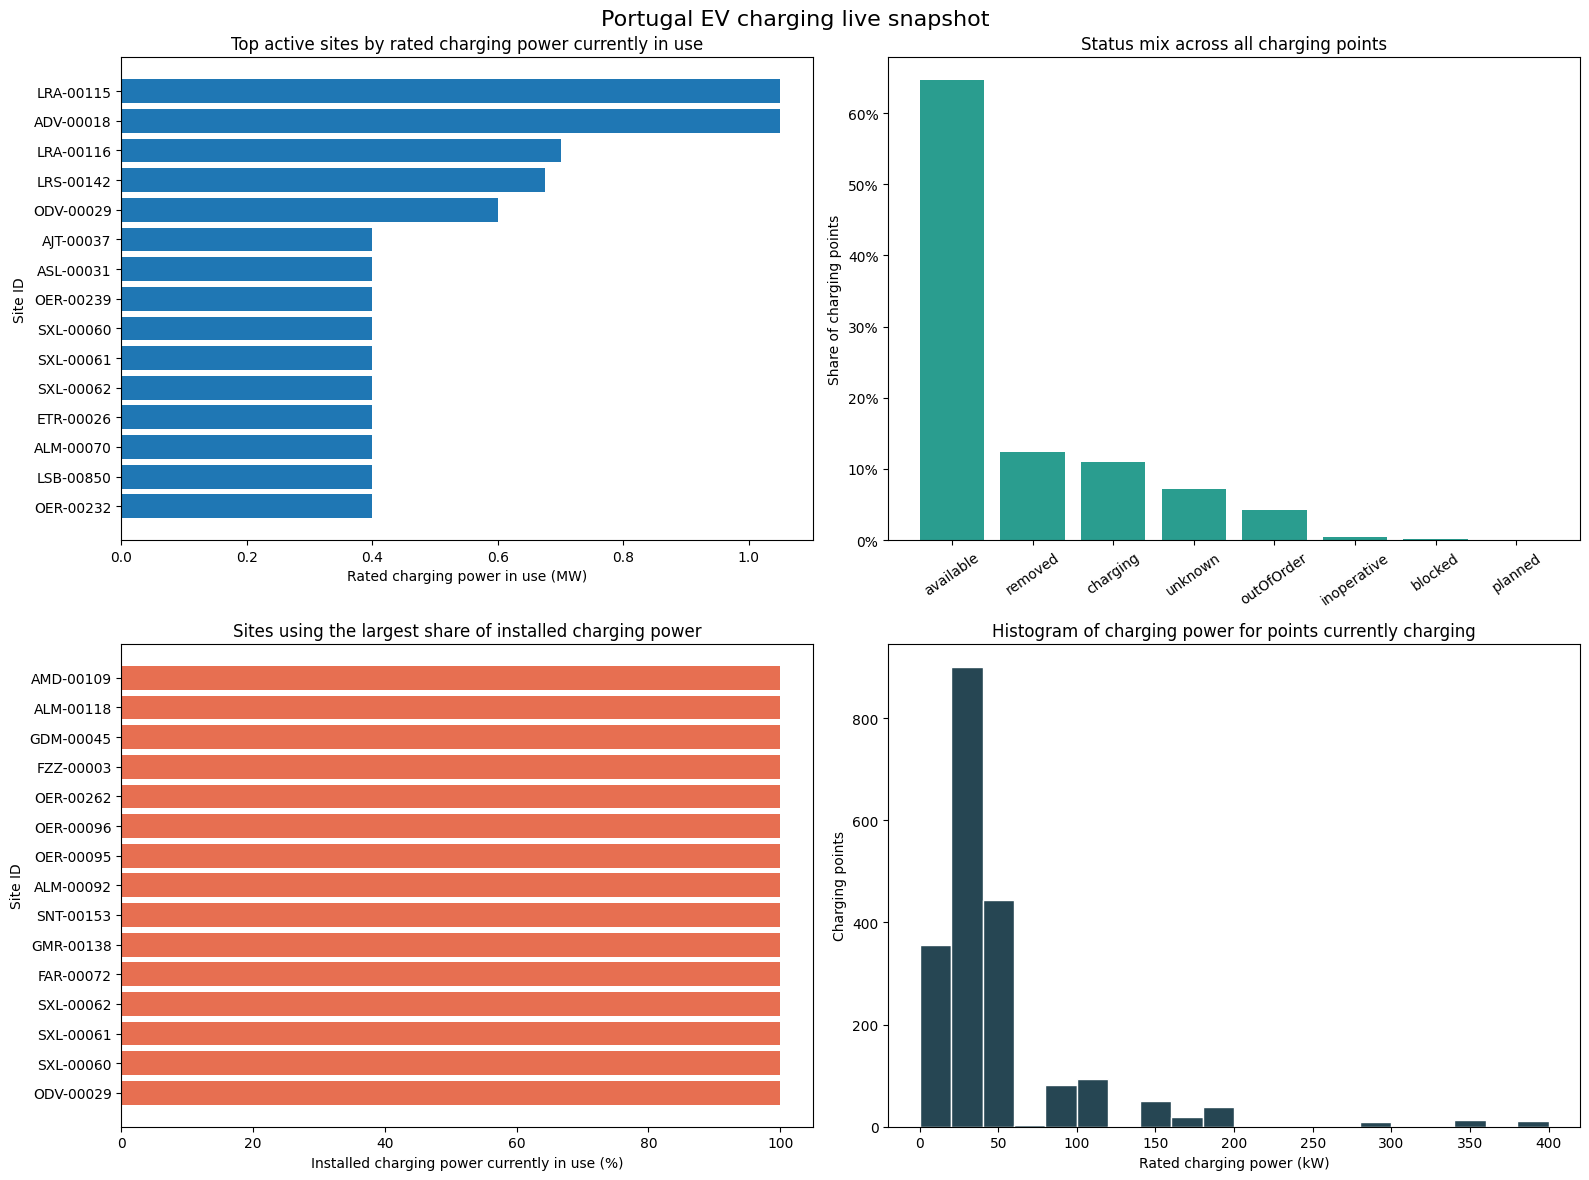

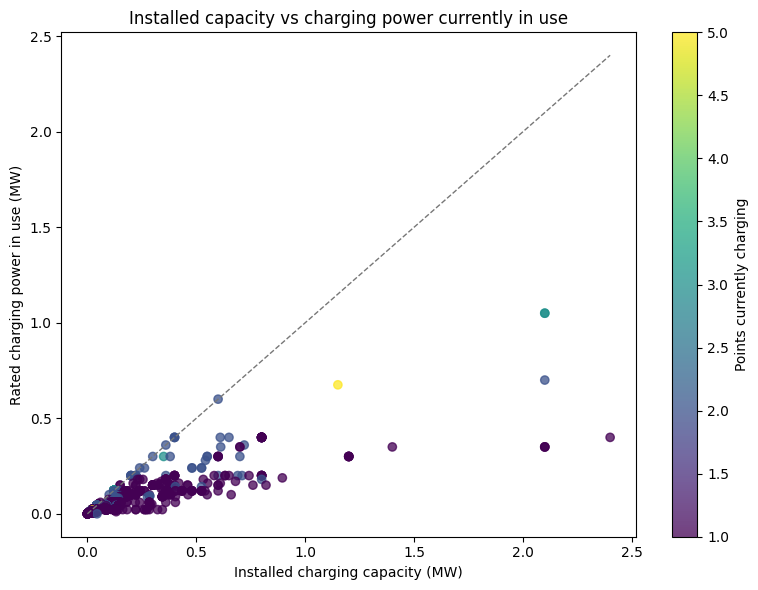

In [5]:
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter



site_live_usage = (

    df.assign(

        is_in_use=df["status"].eq("charging"),

        is_available=df["status"].eq("available"),

        is_faulted=df["status"].isin(["outOfOrder", "inoperative"]),

        active_power_kw=df["point_power_kw"].where(df["status"].eq("charging"), 0),

        in_use_without_power=df["status"].eq("charging") & df["point_power_kw"].isna(),

    )

    .groupby("site_id", dropna=False)

    .agg(

        total_points=("point_id", "size"),

        in_use_points=("is_in_use", "sum"),

        available_points=("is_available", "sum"),

        faulted_points=("is_faulted", "sum"),

        installed_capacity_kw=("point_power_kw", "sum"),

        active_power_kw=("active_power_kw", "sum"),

        in_use_without_power=("in_use_without_power", "sum"),

    )

    .assign(

        installed_capacity_mw=lambda frame: (frame["installed_capacity_kw"] / 1000).round(3),

        active_power_mw=lambda frame: (frame["active_power_kw"] / 1000).round(3),

        utilization_ratio=lambda frame: frame["in_use_points"] / frame["total_points"],

        power_utilization_ratio=lambda frame: (frame["active_power_kw"] / frame["installed_capacity_kw"].where(frame["installed_capacity_kw"] > 0)).fillna(0),

    )

    .sort_values(["active_power_mw", "in_use_points", "installed_capacity_mw"], ascending=[False, False, False])

    .reset_index()

)



active_sites = site_live_usage.loc[site_live_usage["in_use_points"] > 0].copy()

top_active_sites = active_sites.head(15).sort_values("active_power_mw")

top_power_utilized_sites = (

    active_sites.loc[active_sites["installed_capacity_kw"] > 0]

    .sort_values(["power_utilization_ratio", "active_power_mw", "in_use_points"], ascending=[False, False, False])

    .head(15)

    .sort_values("power_utilization_ratio")

)



charging_points_in_use = int(df["status"].eq("charging").sum())

charging_points_in_use_without_power = int((df["status"].eq("charging") & df["point_power_kw"].isna()).sum())

rated_live_power_mw = round(df.loc[df["status"].eq("charging"), "point_power_kw"].dropna().sum() / 1000, 3)

installed_capacity_mw = round(df["point_power_kw"].dropna().sum() / 1000, 3)

active_capacity_share_pct = round(rated_live_power_mw / installed_capacity_mw * 100, 2) if installed_capacity_mw else pd.NA

average_power_of_active_points_kw = round(df.loc[df["status"].eq("charging"), "point_power_kw"].dropna().mean(), 1)

charging_power_histogram = df.loc[df["status"].eq("charging"), "point_power_kw"].dropna()



system_power_summary = pd.DataFrame({

    "metric": [

        "Points with matched power metadata",

        "Charging points currently in use",

        "Charging points in use without power metadata",

        "Rated charging power currently in use (MW)",

        "Installed charging capacity in dataset (MW)",

        "Share of installed capacity currently in use (%)",

        "Average rated power of active charging points (kW)",

    ],

    "value": [

        int(df["point_power_kw"].notna().sum()),

        charging_points_in_use,

        charging_points_in_use_without_power,

        rated_live_power_mw,

        installed_capacity_mw,

        active_capacity_share_pct,

        average_power_of_active_points_kw,

    ],

})



interesting_sites = active_sites.loc[:, [

    "site_id",

    "total_points",

    "in_use_points",

    "active_power_mw",

    "installed_capacity_mw",

    "power_utilization_ratio",

    "faulted_points",

]].head(10)



display(system_power_summary)

display(interesting_sites)



fig, axes = plt.subplots(2, 2, figsize=(16, 12))



axes[0, 0].barh(top_active_sites["site_id"], top_active_sites["active_power_mw"], color="#1f77b4")

axes[0, 0].set_title("Top active sites by rated charging power currently in use")

axes[0, 0].set_xlabel("Rated charging power in use (MW)")

axes[0, 0].set_ylabel("Site ID")



axes[0, 1].bar(status_summary["status"], status_summary["share_pct"], color="#2a9d8f")

axes[0, 1].set_title("Status mix across all charging points")

axes[0, 1].set_ylabel("Share of charging points")

axes[0, 1].yaxis.set_major_formatter(PercentFormatter(100))

axes[0, 1].tick_params(axis="x", rotation=35)



axes[1, 0].barh(top_power_utilized_sites["site_id"], top_power_utilized_sites["power_utilization_ratio"] * 100, color="#e76f51")

axes[1, 0].set_title("Sites using the largest share of installed charging power")

axes[1, 0].set_xlabel("Installed charging power currently in use (%)")

axes[1, 0].set_ylabel("Site ID")



axes[1, 1].hist(charging_power_histogram, bins=20, color="#264653", edgecolor="white")

axes[1, 1].set_title("Histogram of charging power for points currently charging")

axes[1, 1].set_xlabel("Rated charging power (kW)")

axes[1, 1].set_ylabel("Charging points")



fig.suptitle("Portugal EV charging live snapshot", fontsize=16)

fig.tight_layout()

plt.show()



scatter_fig, scatter_ax = plt.subplots(figsize=(8, 6))

scatter = scatter_ax.scatter(

    active_sites["installed_capacity_mw"],

    active_sites["active_power_mw"],

    c=active_sites["in_use_points"],

    cmap="viridis",

    alpha=0.75,

)

max_axis_value = float(active_sites[["installed_capacity_mw", "active_power_mw"]].max().max())

scatter_ax.plot([0, max_axis_value], [0, max_axis_value], linestyle="--", color="#777777", linewidth=1)

scatter_ax.set_title("Installed capacity vs charging power currently in use")

scatter_ax.set_xlabel("Installed charging capacity (MW)")

scatter_ax.set_ylabel("Rated charging power in use (MW)")

scatter_fig.colorbar(scatter, ax=scatter_ax, label="Points currently charging")

scatter_fig.tight_layout()

plt.show()


## Evolution of charging power over time



The chart below reads the minute-by-minute history collected from the live status feed and shows how the total rated charging power currently in use evolves over time, in MW.


,snapshot_id,live_publication_time_utc,collected_at_utc,point_count,charging_point_count,available_point_count,rated_live_power_mw,rolling_mean_mw
263,264,2026-03-16 18:19:50.980000+00:00,2026-03-16 18:21:45.523991+00:00,18469,2064,11859,101.408300,100.151574
264,265,2026-03-16 18:24:51.341000+00:00,2026-03-16 18:26:45.528013+00:00,18469,2049,11890,98.311878,99.898406
265,266,2026-03-16 18:29:51.170000+00:00,2026-03-16 18:31:45.532188+00:00,18469,2060,11876,100.597350,100.182492
266,267,2026-03-16 18:34:51.075000+00:00,2026-03-16 18:36:45.534721+00:00,18469,2103,11819,105.189400,101.171746
267,268,2026-03-16 19:04:53.327000+00:00,2026-03-16 19:09:04.132868+00:00,18469,2061,11897,102.610171,101.623420
268,269,2026-03-16 19:09:53.642000+00:00,2026-03-16 19:11:14.191888+00:00,18469,2040,11939,101.354341,101.612628
269,270,2026-03-16 19:14:51.339000+00:00,2026-03-16 19:16:14.200063+00:00,18469,2026,11944,98.361963,101.622645
270,271,2026-03-16 19:19:51.067000+00:00,2026-03-16 19:21:38.343932+00:00,18469,2029,11933,96.418563,100.786888
271,272,2026-03-16 19:24:50.933000+00:00,2026-03-16 19:26:55.018815+00:00,18469,2042,11935,99.042991,99.557606
272,273,2026-03-16 19:29:51.267000+00:00,2026-03-16 19:31:14.782974+00:00,18469,2051,11908,98.941599,98.823891


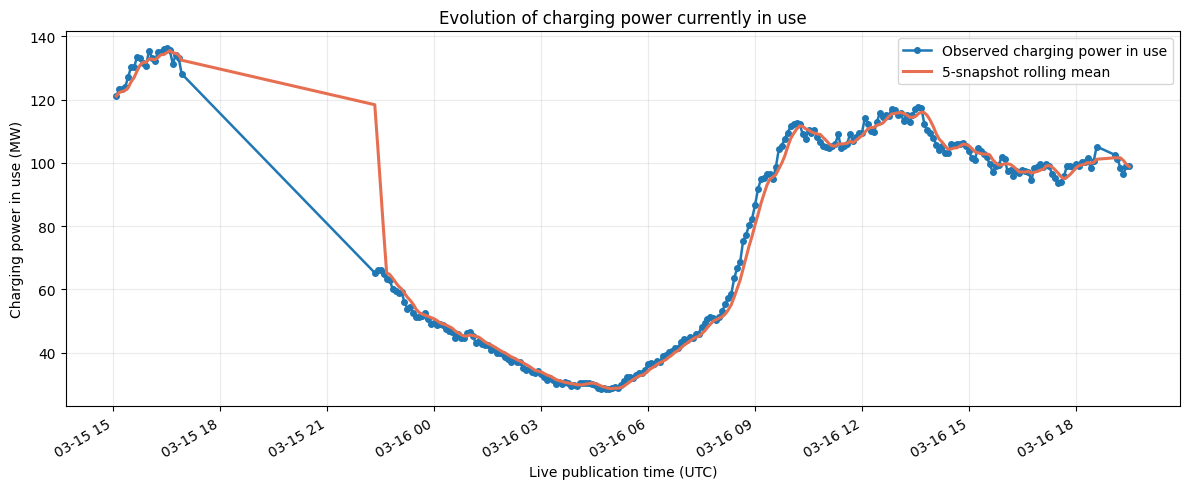

In [8]:
from pathlib import Path

import sqlite3



history_db_path = Path("data") / "ev_status_history.sqlite"



if not history_db_path.exists():

    raise FileNotFoundError(f"History database not found at {history_db_path.resolve()}")



with sqlite3.connect(history_db_path) as connection:

    power_history = pd.read_sql_query(

        """

        SELECT

            snapshot_id,

            live_publication_time_utc,

            collected_at_utc,

            point_count,

            charging_point_count,

            available_point_count,

            rated_live_power_mw

        FROM snapshot_runs

        ORDER BY live_publication_time_utc

        """,

        connection,

    )



power_history["live_publication_time_utc"] = pd.to_datetime(power_history["live_publication_time_utc"], utc=True)

power_history["collected_at_utc"] = pd.to_datetime(power_history["collected_at_utc"], utc=True)

power_history["rolling_mean_mw"] = power_history["rated_live_power_mw"].rolling(window=5, min_periods=1).mean()



display(power_history.tail(10))



history_fig, history_ax = plt.subplots(figsize=(12, 5))

history_ax.plot(

    power_history["live_publication_time_utc"],

    power_history["rated_live_power_mw"],

    marker="o",

    linewidth=1.8,

    markersize=4,

    color="#1f77b4",

    label="Observed charging power in use",

)

history_ax.plot(

    power_history["live_publication_time_utc"],

    power_history["rolling_mean_mw"],

    linewidth=2.2,

    color="#e76f51",

    label="5-snapshot rolling mean",

)

history_ax.set_title("Evolution of charging power currently in use")

history_ax.set_xlabel("Live publication time (UTC)")

history_ax.set_ylabel("Charging power in use (MW)")

history_ax.grid(alpha=0.25)

history_ax.legend()

history_fig.autofmt_xdate()

history_fig.tight_layout()

plt.show()
